<a href="https://colab.research.google.com/github/071210/AQI-Prediction/blob/main/Copy_of_ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
from tabulate import tabulate
import joblib
import seaborn as sns
from scipy.stats import normaltest

In [ ]:
file_path = '/content/kuala lumpur data.xlsx'  # Adjust path if needed
air_quality_data = pd.read_excel(file_path)
air_quality_data['date'] = pd.to_datetime(air_quality_data['date'])
air_quality_data.set_index('date', inplace=True)
air_quality_data.ffill(inplace=True)

In [ ]:
# Resample to monthly frequency
air_quality_data = air_quality_data.resample('MS').ffill()
air_quality_data.index.freq = 'MS'

print("First 5 rows of the processed DataFrame:")
print(air_quality_data.head())
print("\nData summary:")
print(air_quality_data.describe())

First 5 rows of the processed DataFrame:
               CO     NO2     O3  PM 10  PM 2.5     SO2        AQI
date                                                              
2017-01-01  0.561  0.0076  0.015  38.00     NaN  0.0023  35.185185
2017-02-01  0.530  0.0071  0.018  40.89     NaN  0.0025  37.861111
2017-03-01  0.589  0.0082  0.017  42.31     NaN  0.0028  39.175926
2017-04-01  0.662  0.0087  0.015  37.76     NaN  0.0027  34.962963
2017-05-01  0.662  0.0087  0.015  37.76     NaN  0.0027  34.962963

Data summary:
              CO        NO2         O3      PM 10     PM 2.5        SO2  \
count  72.000000  72.000000  72.000000  72.000000  60.000000  72.000000   
mean    0.592764   0.006772   0.016694  24.233889  14.846167   0.001214   
std     0.073744   0.001123   0.002504   8.022845   6.326565   0.000440   
min     0.473000   0.003200   0.013000  16.840000  10.020000   0.000900   
25%     0.534750   0.006100   0.015000  19.127500  11.712500   0.001000   
50%     0.573500   0.0067

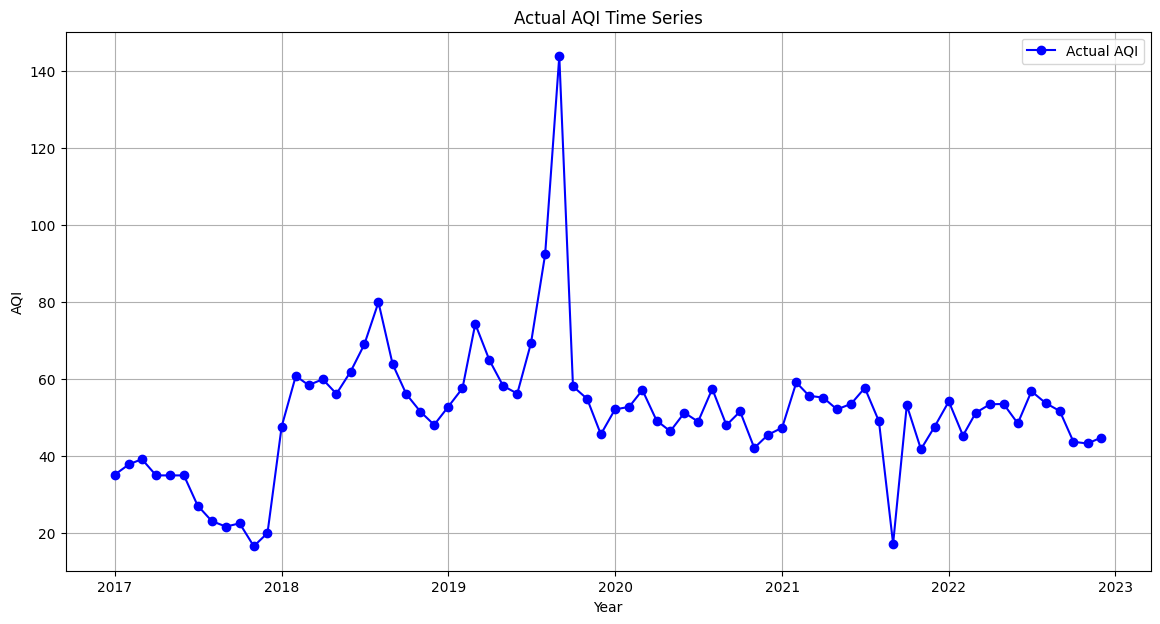

In [ ]:
# Plot the actual AQI data
plt.figure(figsize=(14, 7))
plt.plot(air_quality_data.index, air_quality_data['AQI'],
         label='Actual AQI', color='blue', marker='o')
plt.title('Actual AQI Time Series')
plt.xlabel('Year')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.show()

Trend: A long-term increase in AQI levels over years due to industrial growth.

Seasonality: Higher AQI during specific months, such as during winter due to weather-related factors.

Residual: Random spikes caused by unexpected events, such as wildfires or heavy traffic.

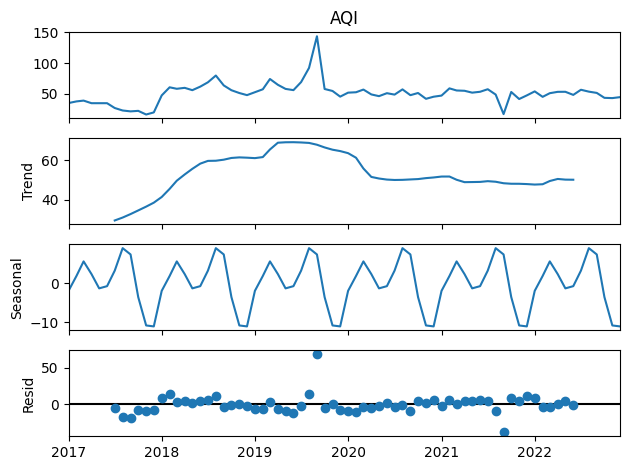

In [ ]:
# Seasonal Decomposition
decomposition = seasonal_decompose(air_quality_data['AQI'], period=12)
decomposition.plot()
plt.tight_layout()
plt.show()

Null Hypothesis (H₀): The time series has a unit root (non-stationary).

Alternative Hypothesis (H₁): The time series is stationary (no unit root).

If p-value > 0.05:
Fail to reject the null hypothesis.
The time series is likely non-stationary.
You may need to difference the data to make it stationary.

If p-value ≤ 0.05:
Reject the null hypothesis.
The time series is likely stationary, and no further transformation is needed.

In [ ]:
# ARIMA Model
# Perform the ADF test
adf_test = adfuller(air_quality_data['AQI'])
adf_statistic, p_value = adf_test[0], adf_test[1]
print(f"ADF Test Statistic: {adf_statistic}")
print(f"p-value: {p_value}")
if p_value > 0.05:
    print("Series is likely non-stationary. Consider differencing the data.")

ADF Test Statistic: -4.0765504558281345
p-value: 0.0010586689567513416


ACF Plot: Used to determine the overall correlation of lagged values in the time series, helping to select the MA (Moving Average) parameter.

PACF Plot: Used to determine the independent influence of a specific lagged value on the current value, helping to select the AR (Autoregressive) parameter.

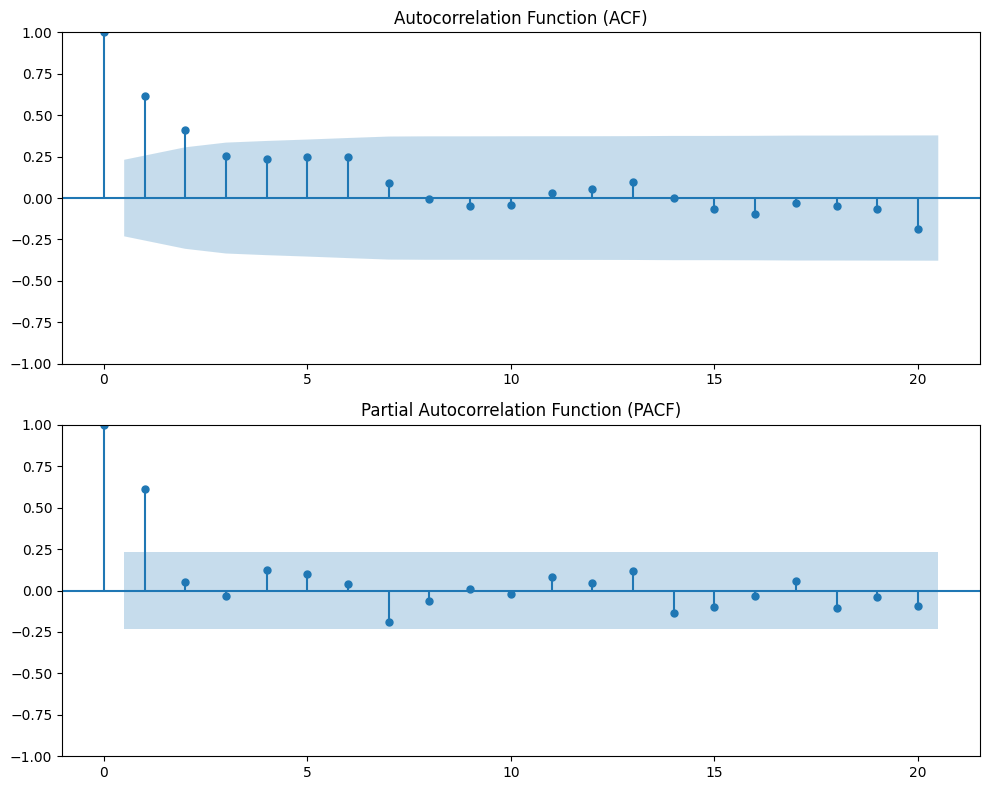

In [ ]:
# ACF and PACF plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(air_quality_data['AQI'], lags=20, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')
plot_pacf(air_quality_data['AQI'], lags=20, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

In [ ]:
def walk_forward_arima_evaluation(series, order=(1, 0, 2), n_splits=5):
    """
    Perform walk-forward time-series cross-validation for an ARIMA model.
    Returns RMSE, MAE, and dictionary of fold predictions.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmse_scores, mae_scores = [], []
    fold_predictions = {}

    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(series)):
        # Split into train/test for this fold
        train_data = series.iloc[train_idx]
        test_data  = series.iloc[test_idx]

        # We'll do single-step-ahead forecasting in a walk-forward manner
        history = train_data.copy()
        preds = []

        for t in range(len(test_data)):
            # Explicitly pass frequency to ARIMA model
            model = ARIMA(history, order=order, freq='MS') # Pass freq='MS' here
            model_fit = model.fit()

            # Forecast one step
            one_step_forecast = model_fit.forecast(steps=1)
            preds.append(one_step_forecast.iloc[0])

            # Append the actual data point to 'history' before next step
            # Use pd.concat instead of append
            history = pd.concat([history, pd.Series(test_data.iloc[t], index=[test_data.index[t]])])

        # Convert predictions list to a Series
        preds_series = pd.Series(preds, index=test_data.index, name='prediction')

        # Compute metrics for this fold
        rmse_fold = np.sqrt(mean_squared_error(test_data, preds_series))
        mae_fold  = mean_absolute_error(test_data, preds_series)
        rmse_scores.append(rmse_fold)
        mae_scores.append(mae_fold)

        fold_predictions[fold_idx] = pd.DataFrame({
            'actual': test_data,
            'predicted': preds_series
        })

        print(f"Fold {fold_idx+1}/{n_splits}: RMSE={rmse_fold:.2f}, MAE={mae_fold:.2f}")

    return rmse_scores, mae_scores, fold_predictions

In [ ]:
# ARIMA model evaluation
y_arima = air_quality_data['AQI']
arima_order = (1, 0, 2)
print("\n============ ARIMA: Time-Series Cross-Validation ============")
rmse_scores_arima, mae_scores_arima, fold_preds_arima = walk_forward_arima_evaluation(
    y_arima, order=arima_order, n_splits=5
)

mean_rmse_arima = np.mean(rmse_scores_arima)
mean_mae_arima = np.mean(mae_scores_arima)
print(f"\nOverall CV RMSE (ARIMA): {mean_rmse_arima:.2f}")
print(f"Overall CV MAE  (ARIMA): {mean_mae_arima:.2f}")

# Train final ARIMA model on the entire dataset
print("\nTraining final ARIMA model on the entire dataset...")
final_arima_model = ARIMA(y_arima, order=arima_order).fit()

# Ljung-Box test on residuals
lb_test_in_sample = acorr_ljungbox(final_arima_model.resid, lags=[10])
print("\nLjung-Box Test p-value (lag=10):", lb_test_in_sample.iloc[0, 1])




============ ARIMA: Time-Series Cross-Validation ============


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWar

Fold 1/5: RMSE=12.74, MAE=9.79


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

Fold 2/5: RMSE=37.08, MAE=21.70


...

Fold 3/5: RMSE=4.96, MAE=4.19


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

Fold 4/5: RMSE=13.02, MAE=7.99


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

Fold 5/5: RMSE=4.67, MAE=3.85

Overall CV RMSE (ARIMA): 14.49
Overall CV MAE  (ARIMA): 9.50

Training final ARIMA model on the entire dataset...

Ljung-Box Test p-value (lag=10): 0.8537729235360745


Ljung-Box Test:

Tests whether the residuals are autocorrelated.

The null hypothesis (H₀): Residuals are independent (no autocorrelation).

If the p-values > 0.05 for all lags, the residuals are likely white noise, indicating a good model fit.

In [ ]:
# Function to categorize AQI
def categorize_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200:
        return 'Unhealthy'
    elif aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

In [ ]:
# Future forecast steps
forecast_steps = 12
future_forecast = final_arima_model.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(
    start=air_quality_data.index[-1] + pd.DateOffset(months=1),
    periods=forecast_steps,
    freq='MS'
)
forecast_values = future_forecast.predicted_mean
forecast_ci = future_forecast.conf_int()

forecast_df = pd.DataFrame({
    'Date': forecast_index,
    'Forecasted_AQI': forecast_values,
    'Lower_CI': forecast_ci.iloc[:, 0],
    'Upper_CI': forecast_ci.iloc[:, 1]
})
forecast_df['AQI_Category'] = forecast_df['Forecasted_AQI'].apply(categorize_aqi)

print("\nARIMA Future AQI Predictions:")
print(tabulate(forecast_df.round(2), headers='keys', tablefmt='pretty', showindex=False))


ARIMA Future AQI Predictions:
+---------------------+----------------+----------+----------+--------------+
|        Date         | Forecasted_AQI | Lower_CI | Upper_CI | AQI_Category |
+---------------------+----------------+----------+----------+--------------+
| 2023-01-01 00:00:00 |     47.09      |  20.43   |  73.76   |     Good     |
| 2023-02-01 00:00:00 |     48.61      |  17.58   |  79.65   |     Good     |
| 2023-03-01 00:00:00 |     49.54      |   16.5   |  82.59   |     Good     |
| 2023-04-01 00:00:00 |     50.06      |  16.43   |  83.68   |   Moderate   |
| 2023-05-01 00:00:00 |     50.34      |  16.53   |  84.14   |   Moderate   |
| 2023-06-01 00:00:00 |     50.49      |  16.64   |  84.35   |   Moderate   |
| 2023-07-01 00:00:00 |     50.58      |  16.71   |  84.45   |   Moderate   |
| 2023-08-01 00:00:00 |     50.63      |  16.75   |  84.51   |   Moderate   |
| 2023-09-01 00:00:00 |     50.65      |  16.77   |  84.53   |   Moderate   |
| 2023-10-01 00:00:00 |     50.67

In [ ]:
# Function to create features for the Random Forest model
def create_features(df, target_col, lag=3):
    """
    Create lagged features for the specified target column.
    """
    df = df.copy()
    for i in range(1, lag + 1):
        df[f'{target_col}_lag_{i}'] = df[target_col].shift(i)
    df.dropna(inplace=True)
    return df

In [ ]:
# Random Forest Model
# Create lag features
rf_data = create_features(air_quality_data, 'AQI')
X = rf_data.drop(columns=['AQI'])
y = rf_data['AQI']

# TimeSeriesSplit for Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
for train_idx, test_idx in tscv.split(X):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    rf_model_cv = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model_cv.fit(X_train_cv, y_train_cv)
    pred_cv = rf_model_cv.predict(X_test_cv)
    cv_scores.append(r2_score(y_test_cv, pred_cv))

print(f"\nRandom Forest CV Scores (R²): {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f}")



Random Forest CV Scores (R²): 0.596 ± 0.298


In [ ]:
rf_data = create_features(air_quality_data, 'AQI', lag=3)
X = rf_data.drop(columns=['AQI'])
y = rf_data['AQI']

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
fold_preds_rf = {}  # Initialize an empty dictionary to store fold predictions

print("\n============ Random Forest: Time-Series Cross-Validation ============")
for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    rf_model_cv = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model_cv.fit(X_train_cv, y_train_cv)
    pred_cv = rf_model_cv.predict(X_test_cv)
    score_cv = r2_score(y_test_cv, pred_cv)
    cv_scores.append(score_cv)
    print(f"Fold {fold_idx+1}/5: R² = {score_cv:.3f}")

    # Store fold predictions in the dictionary
    fold_preds_rf[fold_idx] = pd.DataFrame({
        'actual': y_test_cv,
        'predicted': pred_cv
    })


print(f"\nRandom Forest CV R²: {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f}")


============ Random Forest: Time-Series Cross-Validation ============
Fold 1/5: R² = 0.668
Fold 2/5: R² = 0.520
Fold 3/5: R² = 0.777
Fold 4/5: R² = 0.069
Fold 5/5: R² = 0.948

Random Forest CV R²: 0.596 ± 0.298


Use AQI Lag - Including lagged features improves the model’s ability to predict future AQI, as it uses both pollutant levels and historical AQI trends.

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)
rf_predictions = rf_model.predict(X)

rmse_rf = np.sqrt(mean_squared_error(y, rf_predictions))
mae_rf = mean_absolute_error(y, rf_predictions)
r2_rf = r2_score(y, rf_predictions)
mape_rf = np.mean(np.abs((y - rf_predictions) / y)) * 100
accuracy_rf = 100 - mape_rf

print(f"\nRandom Forest Model Performance on Whole Dataset:")
print(f"RMSE:      {rmse_rf:.2f}")
print(f"MAE:       {mae_rf:.2f}")
print(f"R-squared: {r2_rf:.2f}")
print(f"MAPE:      {mape_rf:.2f}%")
print(f"Accuracy:  {accuracy_rf:.2f}%")



Random Forest Model Performance on Whole Dataset:
RMSE:      3.84
MAE:       1.21
R-squared: 0.94
MAPE:      2.47%
Accuracy:  97.53%


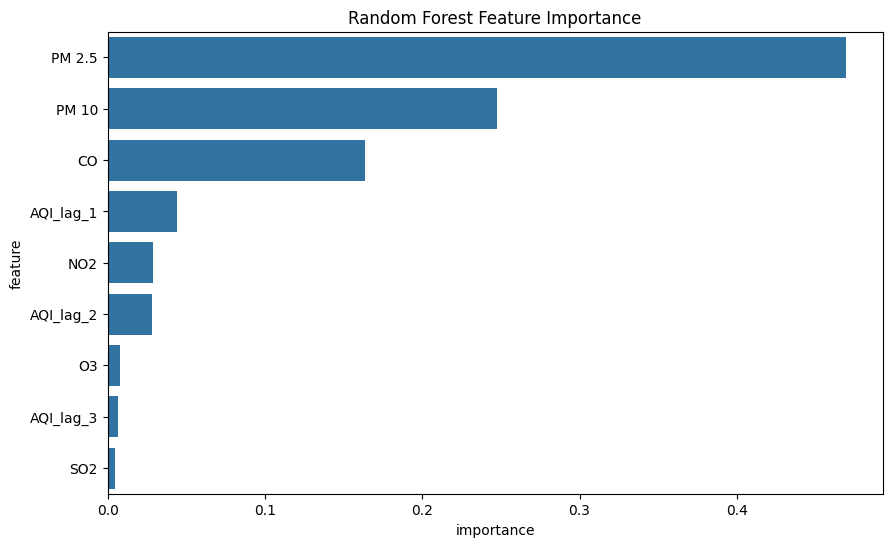

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Random Forest Feature Importance')
plt.show()


In [ ]:
# ------------------------------
#  RANDOM FOREST Prediction Intervals (approx.)
# ------------------------------
rf_lower = RandomForestRegressor(n_estimators=100, random_state=42)
rf_upper = RandomForestRegressor(n_estimators=100, random_state=42)

residuals_std = np.std(y - rf_predictions)
rf_lower.fit(X, y - residuals_std)
rf_upper.fit(X, y + residuals_std)


# ------------------------------
#  RANDOM FOREST Future Forecast (12 steps)
# ------------------------------
future_lagged_values = rf_data.iloc[-1][[col for col in rf_data.columns if col != 'AQI']].values.reshape(1, -1)
future_lagged_values = pd.DataFrame(
    future_lagged_values,
    columns=[col for col in rf_data.columns if col != 'AQI']
)

rf_forecast_values = []
rf_lower_pred = []
rf_upper_pred = []

for _ in range(forecast_steps):
    rf_pred = rf_model.predict(future_lagged_values)[0]
    lower = rf_lower.predict(future_lagged_values)[0]
    upper = rf_upper.predict(future_lagged_values)[0]

    rf_forecast_values.append(rf_pred)
    rf_lower_pred.append(lower)
    rf_upper_pred.append(upper)

    # Shift feature window
    rolled_vals = np.roll(future_lagged_values.values, -1, axis=1)
    future_lagged_values = pd.DataFrame(
        rolled_vals,
        columns=[col for col in rf_data.columns if col != 'AQI']
    )
    # Update the newest lag with the latest prediction
    future_lagged_values.iloc[0, -1] = rf_pred

rf_forecast_df = pd.DataFrame({
    'Date': forecast_index,
    'Forecasted_AQI': rf_forecast_values,
    'Lower_CI': rf_lower_pred,
    'Upper_CI': rf_upper_pred
})
rf_forecast_df['AQI_Category'] = rf_forecast_df['Forecasted_AQI'].apply(categorize_aqi)

print("\nRandom Forest Future AQI Predictions:")
print(tabulate(rf_forecast_df.round(2), headers='keys', tablefmt='pretty', showindex=False))



Random Forest Future AQI Predictions:
+---------------------+----------------+----------+----------+--------------------------------+
|        Date         | Forecasted_AQI | Lower_CI | Upper_CI |          AQI_Category          |
+---------------------+----------------+----------+----------+--------------------------------+
| 2023-01-01 00:00:00 |     45.08      |  41.21   |  48.87   |              Good              |
| 2023-02-01 00:00:00 |     46.27      |  40.45   |  51.22   |              Good              |
| 2023-03-01 00:00:00 |     74.46      |  68.85   |  75.83   |            Moderate            |
| 2023-04-01 00:00:00 |     101.91     |  97.63   |  103.02  | Unhealthy for Sensitive Groups |
| 2023-05-01 00:00:00 |     105.03     |  101.71  |  105.29  | Unhealthy for Sensitive Groups |
| 2023-06-01 00:00:00 |      94.8      |  89.43   |  98.52   |            Moderate            |
| 2023-07-01 00:00:00 |     113.11     |  109.96  |  113.73  | Unhealthy for Sensitive Groups |
|

In [ ]:
# Model Comparison
arima_in_sample_preds = final_arima_model.fittedvalues
arima_in_sample_rmse = np.sqrt(mean_squared_error(y_arima, arima_in_sample_preds))
arima_in_sample_mae  = mean_absolute_error(y_arima, arima_in_sample_preds)
arima_in_sample_r2   = r2_score(y_arima, arima_in_sample_preds)
arima_in_sample_mape = np.mean(np.abs((y_arima - arima_in_sample_preds) / y_arima)) * 100
arima_in_sample_acc  = 100 - arima_in_sample_mape

comparison_table = pd.DataFrame({
    'Metric':       ['RMSE', 'MAE', 'R-squared', 'MAPE (%)', 'Accuracy (%)'],
    'ARIMA':        [arima_in_sample_rmse, arima_in_sample_mae, arima_in_sample_r2, arima_in_sample_mape, arima_in_sample_acc],
    'RandomForest': [rmse_rf, mae_rf, r2_rf, mape_rf, accuracy_rf]
})
print("\nModel Comparison (In-sample for ARIMA vs. Full for RF):")
print(tabulate(comparison_table.round(2), headers='keys', tablefmt='pretty', showindex=False))


Model Comparison (In-sample for ARIMA vs. Full for RF):
+--------------+-------+--------------+
|    Metric    | ARIMA | RandomForest |
+--------------+-------+--------------+
|     RMSE     | 13.65 |     3.84     |
|     MAE      | 8.19  |     1.21     |
|  R-squared   | 0.38  |     0.94     |
|   MAPE (%)   | 18.94 |     2.47     |
| Accuracy (%) | 81.06 |    97.53     |
+--------------+-------+--------------+


Residual=Actual AQI−Predicted AQI

Residual Spread
Left: Wider, with more outliers
Right: Tighter, fewer extreme outliers

Patterns in Residuals
Left:
Clear patterns, indicating bias
Right:
Residuals are random, indicating a good fit

Model Fit
Left: Struggles with non-linear patterns	Right: Captures non-linear relationships well

Outliers
Left: Significant outliers present
Right: Fewer and smaller outliers


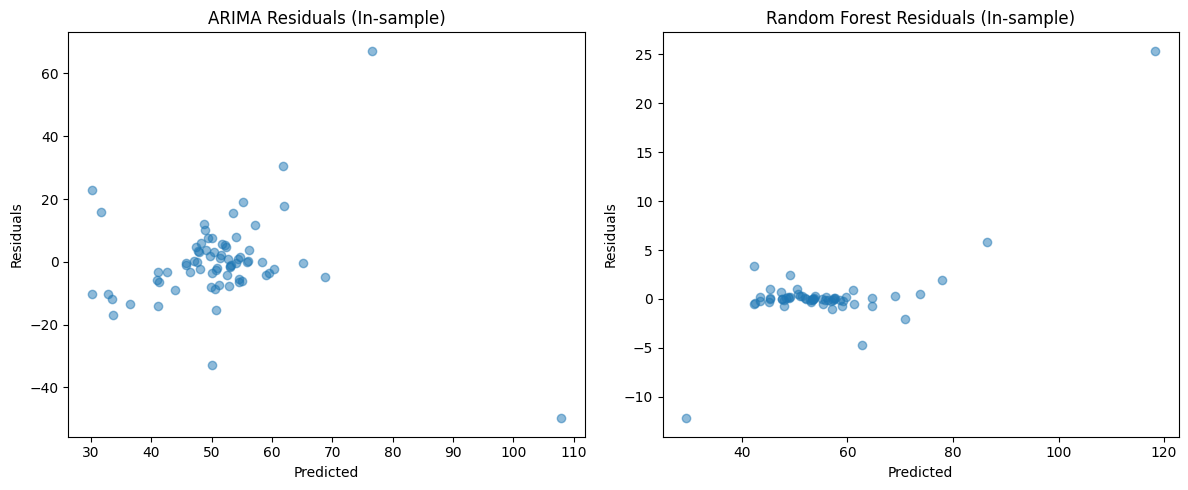

In [ ]:
# Define residuals for the ARIMA test set
residuals_arima = y_arima - arima_in_sample_preds
residuals_rf = y - rf_predictions

plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.scatter(arima_in_sample_preds, residuals_arima, alpha=0.5)
plt.title('ARIMA Residuals (In-sample)')
plt.xlabel('Predicted')
plt.ylabel('Residuals')

plt.subplot(122)
plt.scatter(rf_predictions, residuals_rf, alpha=0.5)
plt.title('Random Forest Residuals (In-sample)')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

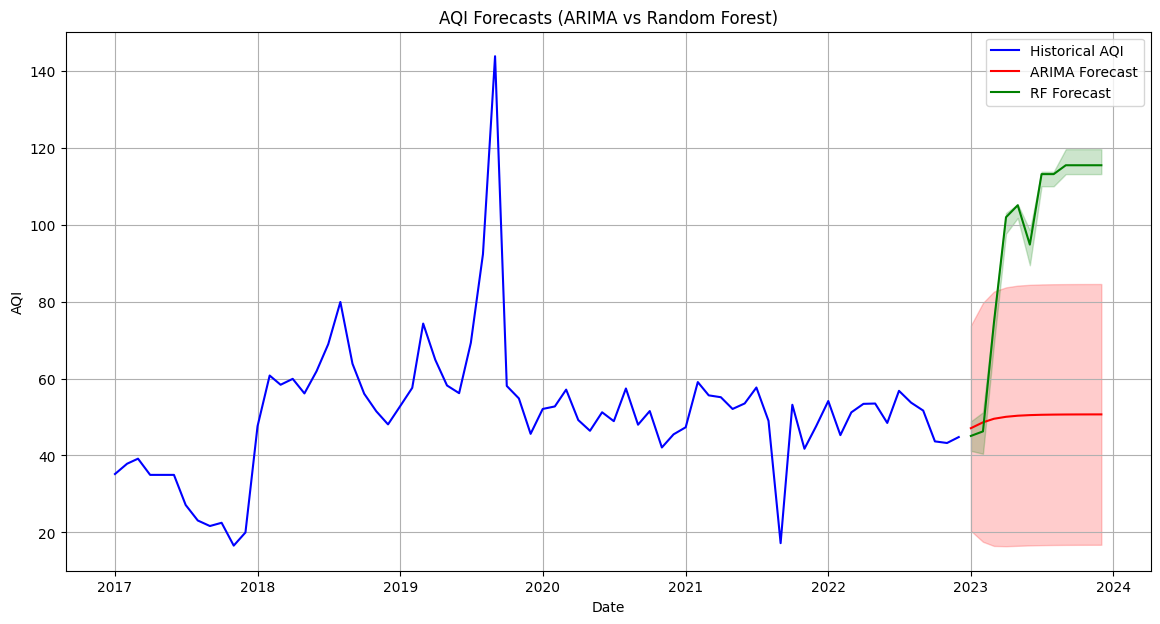

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(y_arima.index, y_arima, label='Historical AQI', color='blue')
plt.plot(forecast_df['Date'], forecast_df['Forecasted_AQI'],
         label='ARIMA Forecast', color='red')
plt.fill_between(forecast_df['Date'],
                 forecast_df['Lower_CI'],
                 forecast_df['Upper_CI'],
                 color='red', alpha=0.2)
plt.plot(rf_forecast_df['Date'], rf_forecast_df['Forecasted_AQI'],
         label='RF Forecast', color='green')
plt.fill_between(rf_forecast_df['Date'],
                 rf_forecast_df['Lower_CI'],
                 rf_forecast_df['Upper_CI'],
                 color='green', alpha=0.2)
plt.title('AQI Forecasts (ARIMA vs Random Forest)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.show()

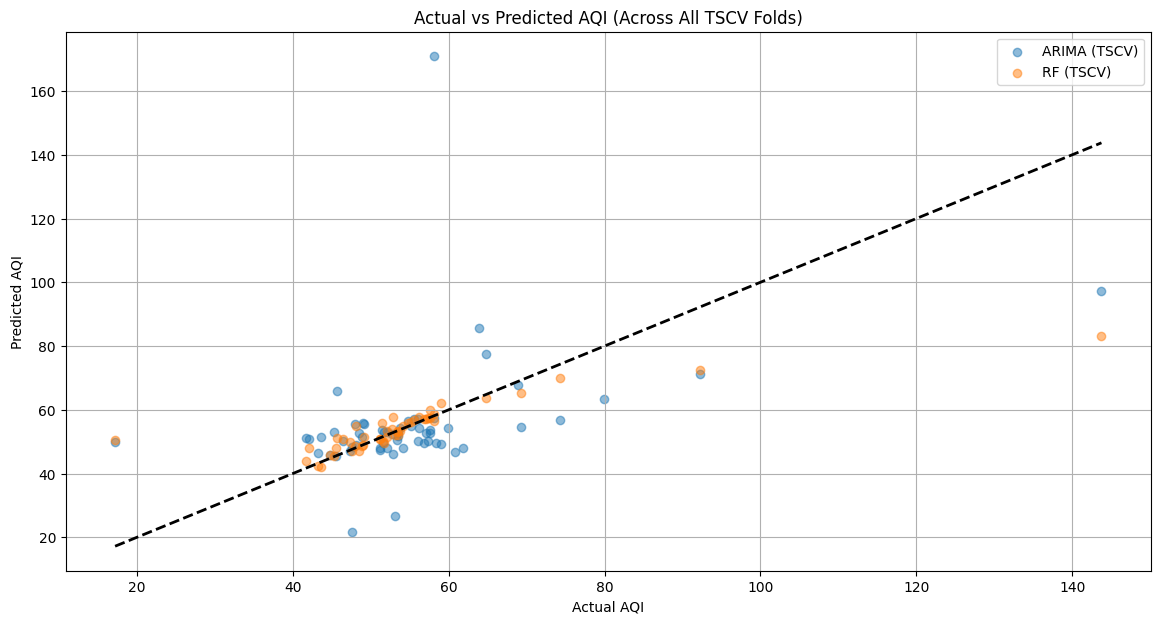

In [ ]:
import matplotlib.pyplot as plt

# Concatenate fold predictions into a single DataFrame for ARIMA
all_folds_arima = pd.concat(fold_preds_arima.values())

# Concatenate fold predictions into a single DataFrame for Random Forest
all_folds_rf = pd.concat(fold_preds_rf.values())

plt.figure(figsize=(14, 7))

# ARIMA scatter
plt.scatter(all_folds_arima['actual'], all_folds_arima['predicted'],
            label='ARIMA (TSCV)', alpha=0.5)

# RF scatter
plt.scatter(all_folds_rf['actual'], all_folds_rf['predicted'],
            label='RF (TSCV)', alpha=0.5)

# 45-degree reference line
min_val = min(all_folds_arima['actual'].min(), all_folds_rf['actual'].min())
max_val = max(all_folds_arima['actual'].max(), all_folds_rf['actual'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI (Across All TSCV Folds)')
plt.legend()
plt.grid(True)
plt.show()




In [ ]:
combined_forecast = pd.merge(
    forecast_df.add_prefix('ARIMA_'),
    rf_forecast_df.add_prefix('RF_'),
    left_on='ARIMA_Date',
    right_on='RF_Date'
)
combined_forecast.to_excel('AQI_Forecast_Results_Final.xlsx', index=False)
print("\nFinal forecast results saved to 'AQI_Forecast_Results_Final.xlsx'")

joblib.dump(rf_model, 'random_forest_aqi_model.pkl')
print("\nRandom Forest model saved to 'random_forest_aqi_model.pkl'")


Final forecast results saved to 'AQI_Forecast_Results_Final.xlsx'

Random Forest model saved to 'random_forest_aqi_model.pkl'


In [ ]:
print("Feature order in the model:")
print(X.columns.tolist())


Feature order in the model:
['CO', 'NO2', 'O3', 'PM 10', 'PM 2.5', 'SO2', 'AQI_lag_1', 'AQI_lag_2', 'AQI_lag_3']


---Zenml MLOps---

In [ ]:
!pip install gradio

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature importance:")
print(feature_importance)


Feature importance:
     feature  importance
4     PM 2.5    0.469244
3      PM 10    0.247336
0         CO    0.163306
6  AQI_lag_1    0.044133
1        NO2    0.028627
7  AQI_lag_2    0.028084
2         O3    0.008077
8  AQI_lag_3    0.006275
5        SO2    0.004919


In [ ]:
import gradio as gr
import joblib
import numpy as np

# Load the Random Forest model
rf_model = joblib.load('random_forest_aqi_model.pkl')

# Prediction function
def predict_rf(co, no2, o3, pm10, pm25, so2, aqi_lag_1, aqi_lag_2, aqi_lag_3):
    try:
        # Combine all features into a single feature vector in the correct order
        features = np.array([co, no2, o3, pm10, pm25, so2, aqi_lag_1, aqi_lag_2, aqi_lag_3]).reshape(1, -1)
        prediction = rf_model.predict(features)
        return f"Predicted AQI: {prediction[0]:.2f}"
    except Exception as e:
        return f"Error: {str(e)}"

# Create Gradio interface with inputs in the correct order
interface = gr.Interface(
    fn=predict_rf,
    inputs=[
        gr.Number(label="CO"),
        gr.Number(label="NO2"),
        gr.Number(label="O3"),
        gr.Number(label="PM 10"),
        gr.Number(label="PM 2.5"),
        gr.Number(label="SO2"),
        gr.Number(label="AQI Lag 1 (Previous Month)"),
        gr.Number(label="AQI Lag 2 (Two Months Ago)"),
        gr.Number(label="AQI Lag 3 (Three Months Ago)")
    ],
    outputs="text",
    title="Random Forest AQI Prediction",
    description="Enter the pollutant levels and previous AQI values to predict the next month's AQI."
)

# Launch the interface
interface.launch()


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://96170ab01e2547cdc5.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


--Deployment Using FLASK--